In [1]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [3]:
uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [4]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

### Valores atipicos

In [5]:
viajes_sin_moverse = uber[
    (uber["dropoff_latitude"] == uber["pickup_latitude"]) & 
    (uber["dropoff_longitude"] == uber["pickup_longitude"]) & 
    (uber["fare_amount"] == 0)]
print(f"Viajes sin movimiento pero sin costos son: {viajes_sin_moverse["passenger_count"].count()}") # Hay 2 viajes sin moverse
viajes_con_movimiento_sin_costo = uber[
    ((uber["dropoff_latitude"] != uber["pickup_latitude"]) | 
    (uber["dropoff_longitude"] != uber["pickup_longitude"])) & 
    (uber["fare_amount"] == 0)]
print(f"Viajes con movimiento pero sin costos son: {viajes_con_movimiento_sin_costo["passenger_count"].count()}") # Hay 3 viajes con movimiento sin costo

Viajes sin movimiento pero sin costos son: 2
Viajes con movimiento pero sin costos son: 3


In [6]:
precios_negativos = uber[uber["fare_amount"] <= 0]
print(f"Viajes con costos negativos: {precios_negativos["passenger_count"].count()}") # hay 22 valores negativos
precios_negativos[["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "fare_amount"]]

Viajes con costos negativos: 22


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount
20744,-73.658897,40.805199,-73.658897,40.805199,0.00
22182,-73.994366,40.755395,-73.998718,40.854853,0.00
63395,-73.992249,40.748936,-73.988518,40.748180,-5.00
71246,-73.952725,40.768235,-73.949928,40.772208,-3.30
79903,-73.982430,40.775024,-73.981750,40.778439,-3.50
87467,-73.969475,40.807503,0.000000,0.000000,0.00
89322,-73.972772,40.785657,-73.972867,40.785500,-49.57
92063,-73.952740,40.768233,-74.007028,40.707338,-23.70
98875,-74.000359,40.728729,-74.005699,40.728680,-52.00
104080,-73.952623,40.766942,-73.953787,40.784882,-7.30


In [7]:
q3 = uber["fare_amount"].quantile(0.75)
q1 = uber["fare_amount"].quantile(0.25)

iqr = q3 - q1
umbral_inferior = max(q1 - 1.5 * iqr,0)
umbral_superior = q3 + 1.5 * iqr

precios_fuera_de_rango = uber[(uber["fare_amount"] < umbral_inferior) | (uber["fare_amount"] > umbral_superior)]
print(f"Viajes con costos fuera de rango: {precios_fuera_de_rango["passenger_count"].count()}") # hay 17173 valores fuera de rango

Viajes con costos fuera de rango: 17173


### Graficos

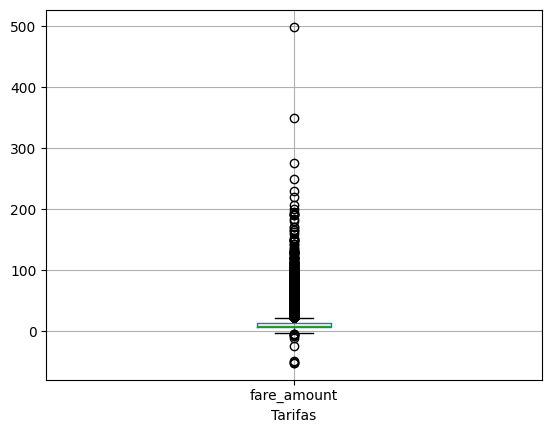

In [8]:
uber.boxplot(column='fare_amount')
plt.xlabel("Tarifas")
plt.show()